# Demo ANN tự xây bằng NumPy

Notebook này phân loại hoa Iris bằng một mạng neural network tự viết. `scikit-learn` chỉ cung cấp dataset qua `load_iris`; model không dùng `MLPClassifier` hay pipeline có sẵn.

Kiến trúc mạng:

```text
4 input features -> 8 hidden neurons with tanh -> 3 output neurons with softmax
```

Mỗi mẫu có bốn số đo: sepal length, sepal width, petal length và petal width. Output là một trong ba loài `setosa`, `versicolor` hoặc `virginica`.

In [2]:
# NumPy xử lý mảng, phép nhân ma trận và gradient update thủ công.
import numpy as np

# Matplotlib dùng để vẽ loss curve, activation và confusion matrix.
import matplotlib.pyplot as plt

# scikit-learn chỉ cung cấp dữ liệu Iris, không cung cấp model ANN.
from sklearn.datasets import load_iris

np.set_printoptions(precision=3, suppress=True)

## 1. Chuẩn bị dữ liệu

Ta chia từng loài theo tỉ lệ 75/25 để cả training set và test set đều có đủ ba lớp. Mean và standard deviation chỉ lấy từ training set, sau đó dùng lại cho test set.

In [3]:
# Dataset có bốn feature cho mỗi bông hoa và một nhãn lớp dạng số nguyên.
iris_dataset = load_iris()
feature_matrix = iris_dataset.data
target_labels = iris_dataset.target

# Dùng random generator riêng để lần chạy lại có cùng cách chia dữ liệu.
random_generator = np.random.default_rng(42)
training_indices_by_class = []
testing_indices_by_class = []

# Giữ 75% của mỗi lớp cho training.
for class_label in np.unique(target_labels):
    class_indices = np.flatnonzero(target_labels == class_label)
    random_generator.shuffle(class_indices)
    training_sample_count = int(0.75 * len(class_indices))
    training_indices_by_class.append(class_indices[:training_sample_count])
    testing_indices_by_class.append(class_indices[training_sample_count:])

training_indices = np.concatenate(training_indices_by_class)
testing_indices = np.concatenate(testing_indices_by_class)
random_generator.shuffle(training_indices)
random_generator.shuffle(testing_indices)

# Giữ dữ liệu gốc để hiển thị input dễ hiểu trong phần trace.
training_features_raw = feature_matrix[training_indices]
training_labels = target_labels[training_indices]
testing_features_raw = feature_matrix[testing_indices]
testing_labels = target_labels[testing_indices]

# Chỉ dùng training set để tính thông số chuẩn hóa.
training_feature_means = training_features_raw.mean(axis=0)
training_feature_stds = training_features_raw.std(axis=0)
training_features = (training_features_raw - training_feature_means) / training_feature_stds
testing_features = (testing_features_raw - training_feature_means) / training_feature_stds

print('Training features:', training_features.shape)
print('Testing features:', testing_features.shape)
print('Class names:', iris_dataset.target_names)

Training features: (111, 4)
Testing features: (39, 4)
Class names: ['setosa' 'versicolor' 'virginica']


In [4]:
# Đổi class ID thành dạng one-hot, ví dụ setosa -> [1, 0, 0].
def one_hot_encode(class_labels, number_of_classes):
    encoded_labels = np.zeros((class_labels.size, number_of_classes))
    encoded_labels[np.arange(class_labels.size), class_labels] = 1
    return encoded_labels

training_one_hot_labels = one_hot_encode(training_labels, number_of_classes=3)
print('One-hot labels:', training_one_hot_labels.shape)

One-hot labels: (111, 3)


## 2. Tự xây ANN

`SimpleANN` có hai lớp chứa weights và bias:

- `input_to_hidden_weights`: shape `(4, 8)`
- `hidden_to_output_weights`: shape `(8, 3)`
- hidden activation: `tanh`
- output activation: `softmax`

Input layer không có weights riêng. Nó chỉ nhận bốn feature đã chuẩn hóa.

In [5]:
# Dịch logits trước khi exp để softmax ổn định hơn với giá trị lớn.
def softmax(logits):
    shifted_logits = logits - logits.max(axis=1, keepdims=True)
    exponentiated_logits = np.exp(shifted_logits)
    return exponentiated_logits / exponentiated_logits.sum(axis=1, keepdims=True)


# Mạng có cấu trúc 4 -> 8 -> 3.
class SimpleANN:
    def __init__(
        self,
        input_feature_count=4,
        hidden_neuron_count=8,
        output_class_count=3,
        learning_rate=0.05,
        random_seed=42,
    ):
        # Đây là các tham số model sẽ học trong quá trình training.
        random_generator = np.random.default_rng(random_seed)
        self.input_to_hidden_weights = random_generator.normal(
            0, 0.5, size=(input_feature_count, hidden_neuron_count)
        )
        self.hidden_layer_biases = np.zeros((1, hidden_neuron_count))
        self.hidden_to_output_weights = random_generator.normal(
            0, 0.5, size=(hidden_neuron_count, output_class_count)
        )
        self.output_layer_biases = np.zeros((1, output_class_count))
        self.learning_rate = learning_rate
        self.loss_history = []

    def forward(self, input_features):
        # Hidden layer: bốn input thành tám giá trị trung gian.
        hidden_layer_pre_activation = (
            input_features @ self.input_to_hidden_weights
            + self.hidden_layer_biases
        )
        hidden_layer_output = np.tanh(hidden_layer_pre_activation)

        # Output layer: tám giá trị hidden thành ba class probabilities.
        output_layer_pre_activation = (
            hidden_layer_output @ self.hidden_to_output_weights
            + self.output_layer_biases
        )
        output_probabilities = softmax(output_layer_pre_activation)

        # Cache giúp backpropagation và giao diện đọc được từng layer.
        forward_cache = {
            'hidden_layer_pre_activation': hidden_layer_pre_activation,
            'hidden_layer_output': hidden_layer_output,
            'output_layer_pre_activation': output_layer_pre_activation,
        }
        return output_probabilities, forward_cache

    def fit(self, input_features, one_hot_targets, epochs=2000):
        training_sample_count = input_features.shape[0]

        # Full-batch gradient descent: mỗi update dùng toàn bộ training set.
        for _ in range(epochs):
            output_probabilities, forward_cache = self.forward(input_features)
            clipped_probabilities = np.clip(output_probabilities, 1e-12, 1.0)

            # Cross-entropy phạt xác suất thấp ở class đúng.
            loss = -np.mean(
                np.sum(one_hot_targets * np.log(clipped_probabilities), axis=1)
            )
            self.loss_history.append(loss)

            # Gradient của softmax kết hợp với cross-entropy.
            output_layer_pre_activation_gradients = (
                output_probabilities - one_hot_targets
            ) / training_sample_count
            hidden_to_output_weight_gradients = (
                forward_cache['hidden_layer_output'].T
                @ output_layer_pre_activation_gradients
            )
            output_layer_bias_gradients = output_layer_pre_activation_gradients.sum(
                axis=0, keepdims=True
            )

            # Truyền gradient ngược qua output layer và đạo hàm của tanh.
            hidden_layer_output_gradients = (
                output_layer_pre_activation_gradients
                @ self.hidden_to_output_weights.T
            )
            hidden_layer_pre_activation_gradients = (
                hidden_layer_output_gradients
                * (1 - forward_cache['hidden_layer_output'] ** 2)
            )
            input_to_hidden_weight_gradients = (
                input_features.T @ hidden_layer_pre_activation_gradients
            )
            hidden_layer_bias_gradients = hidden_layer_pre_activation_gradients.sum(
                axis=0, keepdims=True
            )

            # Cập nhật weights và bias theo hướng làm loss giảm.
            self.hidden_to_output_weights -= (
                self.learning_rate * hidden_to_output_weight_gradients
            )
            self.output_layer_biases -= (
                self.learning_rate * output_layer_bias_gradients
            )
            self.input_to_hidden_weights -= (
                self.learning_rate * input_to_hidden_weight_gradients
            )
            self.hidden_layer_biases -= (
                self.learning_rate * hidden_layer_bias_gradients
            )

        return self

    def predict_proba(self, input_features):
        # Prediction chỉ chạy forward pass, không thay đổi tham số.
        output_probabilities, _ = self.forward(input_features)
        return output_probabilities

    def predict(self, input_features):
        return self.predict_proba(input_features).argmax(axis=1)

    def trace(self, input_features):
        # Trace cung cấp output cho các panel trực quan của notebook.
        output_probabilities, forward_cache = self.forward(input_features)
        return {
            'input': input_features,
            'hidden_pre_activation': forward_cache['hidden_layer_pre_activation'],
            'hidden_output': forward_cache['hidden_layer_output'],
            'output_pre_activation': forward_cache['output_layer_pre_activation'],
            'output_probabilities': output_probabilities,
        }

## 3. Train model

Ở bước này, mạng bắt đầu với weights ngẫu nhiên rồi lặp lại forward pass, tính loss, backpropagation và gradient descent.

In [6]:
neural_network = SimpleANN(
    input_feature_count=4,
    hidden_neuron_count=8,
    output_class_count=3,
    learning_rate=0.05,
    random_seed=42,
)
neural_network.fit(training_features, training_one_hot_labels, epochs=2000)

testing_predictions = neural_network.predict(testing_features)
testing_accuracy = np.mean(testing_predictions == testing_labels)

print(f'Test accuracy: {testing_accuracy:.3f}')

Test accuracy: 1.000


## 4. Kiểm tra kiến trúc mạng

Các shape này xác nhận đúng cấu trúc `4 -> 8 -> 3`.

In [7]:
print('Input -> hidden weights:', neural_network.input_to_hidden_weights.shape)
print('Hidden -> output weights:', neural_network.hidden_to_output_weights.shape)
print('Hidden biases:', neural_network.hidden_layer_biases.shape)
print('Output biases:', neural_network.output_layer_biases.shape)

assert neural_network.input_to_hidden_weights.shape == (4, 8)
assert neural_network.hidden_to_output_weights.shape == (8, 3)
assert neural_network.hidden_layer_biases.shape == (1, 8)
assert neural_network.output_layer_biases.shape == (1, 3)

Input -> hidden weights: (4, 8)
Hidden -> output weights: (8, 3)
Hidden biases: (1, 8)
Output biases: (1, 3)


## 5. Trace input/output của từng layer

Ta chọn một mẫu test và hiển thị dữ liệu ở từng chặng:

```text
raw input (1, 4)
    -> normalized input (1, 4)
    -> hidden output (1, 8)
    -> output probabilities (1, 3)
    -> predicted species
```

In [8]:
sample_index = 0
raw_sample_features = testing_features_raw[sample_index:sample_index + 1]
sample_features = (
    raw_sample_features - training_feature_means
) / training_feature_stds
forward_pass_trace = neural_network.trace(sample_features)

print('Raw input:', raw_sample_features)
print('Raw input shape:', raw_sample_features.shape)
print('Hidden layer input:', forward_pass_trace['input'])
print('Hidden layer input shape:', forward_pass_trace['input'].shape)
print('Hidden layer output:', forward_pass_trace['hidden_output'])
print('Hidden layer output shape:', forward_pass_trace['hidden_output'].shape)
print('Output layer input:', forward_pass_trace['hidden_output'])
print('Output layer output:', forward_pass_trace['output_probabilities'])
print('Output layer output shape:', forward_pass_trace['output_probabilities'].shape)

predicted_class_index = forward_pass_trace['output_probabilities'].argmax()
actual_class_index = testing_labels[sample_index]
print('Actual species:', iris_dataset.target_names[actual_class_index])
print('Predicted species:', iris_dataset.target_names[predicted_class_index])

assert np.isclose(forward_pass_trace['output_probabilities'].sum(), 1.0)

Raw input: [[4.3 3.  1.1 0.1]]
Raw input shape: (1, 4)
Hidden layer input: [[-1.907 -0.21  -1.548 -1.491]]
Hidden layer input shape: (1, 4)
Hidden layer output: [[-1.     0.997 -0.967 -0.693  0.572  0.978 -0.987  0.996]]
Hidden layer output shape: (1, 8)
Output layer input: [[-1.     0.997 -0.967 -0.693  0.572  0.978 -0.987  0.996]]
Output layer output: [[0.993 0.007 0.   ]]
Output layer output shape: (1, 3)
Actual species: setosa
Predicted species: setosa


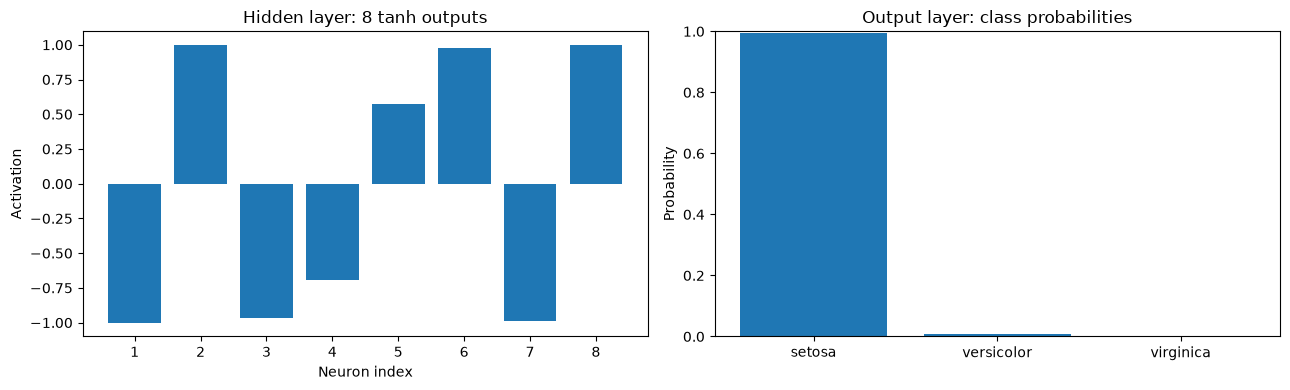

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mỗi cột là output của một neuron trong hidden layer.
hidden_layer_outputs = forward_pass_trace['hidden_output'][0]
axes[0].bar(np.arange(1, 9), hidden_layer_outputs)
axes[0].set_title('Hidden layer: 8 tanh outputs')
axes[0].set_xlabel('Neuron index')
axes[0].set_ylabel('Activation')

# Ba cột cuối cùng là xác suất của ba loài hoa.
output_class_probabilities = forward_pass_trace['output_probabilities'][0]
axes[1].bar(iris_dataset.target_names, output_class_probabilities)
axes[1].set_title('Output layer: class probabilities')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6. Chạy thử nhiều mẫu

Mỗi dòng cho biết nhãn thật, nhãn dự đoán và xác suất của cả ba lớp.

In [10]:
sample_indices = np.linspace(0, len(testing_features) - 1, 5, dtype=int)

for sample_index in sample_indices:
    raw_sample_features = testing_features_raw[sample_index:sample_index + 1]
    sample_features = (
        raw_sample_features - training_feature_means
    ) / training_feature_stds
    sample_probabilities = neural_network.predict_proba(sample_features)[0]
    predicted_class_index = sample_probabilities.argmax()
    actual_class_index = testing_labels[sample_index]

    print(f'Sample {sample_index}')
    print('  Input:', raw_sample_features[0])
    print('  Actual:', iris_dataset.target_names[actual_class_index])
    print('  Predicted:', iris_dataset.target_names[predicted_class_index])
    readable_probabilities = dict(zip(iris_dataset.target_names.tolist(), sample_probabilities.round(3).tolist()))
    print('  Probabilities:', readable_probabilities)
    print()

Sample 0
  Input: [4.3 3.  1.1 0.1]
  Actual: setosa
  Predicted: setosa
  Probabilities: {'setosa': 0.993, 'versicolor': 0.007, 'virginica': 0.0}

Sample 9
  Input: [5.7 2.6 3.5 1. ]
  Actual: versicolor
  Predicted: versicolor
  Probabilities: {'setosa': 0.007, 'versicolor': 0.993, 'virginica': 0.0}

Sample 19
  Input: [5.  2.  3.5 1. ]
  Actual: versicolor
  Predicted: versicolor
  Probabilities: {'setosa': 0.001, 'versicolor': 0.998, 'virginica': 0.001}

Sample 28
  Input: [5.  3.2 1.2 0.2]
  Actual: setosa
  Predicted: setosa
  Probabilities: {'setosa': 0.993, 'versicolor': 0.007, 'virginica': 0.0}

Sample 38
  Input: [5.5 2.5 4.  1.3]
  Actual: versicolor
  Predicted: versicolor
  Probabilities: {'setosa': 0.002, 'versicolor': 0.994, 'virginica': 0.005}



## 7. Đánh giá model

Accuracy chỉ là một kết quả của lần chạy với cấu hình hiện tại. Loss curve cho thấy quá trình học, còn confusion matrix cho thấy model nhầm lớp nào với lớp nào.

Test accuracy: 1.000
Initial loss: 1.0435
Final loss: 0.0592


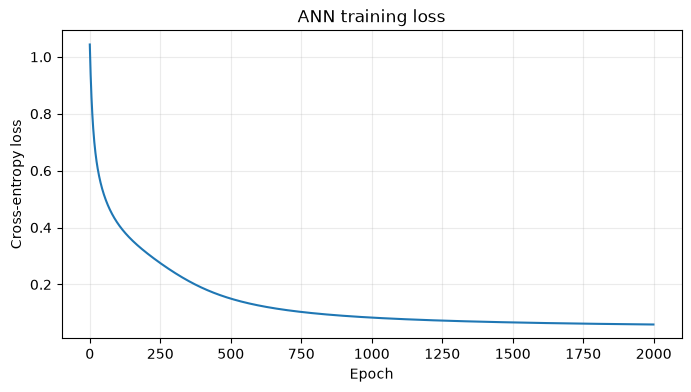

In [11]:
print(f'Test accuracy: {testing_accuracy:.3f}')
print(f'Initial loss: {neural_network.loss_history[0]:.4f}')
print(f'Final loss: {neural_network.loss_history[-1]:.4f}')

assert neural_network.loss_history[-1] < neural_network.loss_history[0]
assert np.allclose(
    neural_network.predict_proba(testing_features).sum(axis=1),
    1.0,
    atol=1e-6,
)

figure, axis = plt.subplots(figsize=(8, 4))
axis.plot(neural_network.loss_history)
axis.set_title('ANN training loss')
axis.set_xlabel('Epoch')
axis.set_ylabel('Cross-entropy loss')
axis.grid(alpha=0.25)
plt.show()

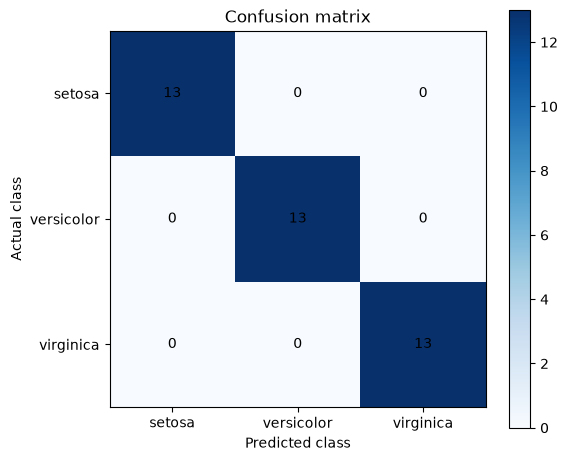

In [12]:
# Hàng là lớp thật, cột là lớp model dự đoán.
confusion_matrix = np.zeros((3, 3), dtype=int)
for actual_class_index, predicted_class_index in zip(
    testing_labels, testing_predictions
):
    confusion_matrix[actual_class_index, predicted_class_index] += 1

figure, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(confusion_matrix, cmap='Blues')
axis.set_xticks(range(3), iris_dataset.target_names)
axis.set_yticks(range(3), iris_dataset.target_names)
axis.set_xlabel('Predicted class')
axis.set_ylabel('Actual class')
axis.set_title('Confusion matrix')
figure.colorbar(image, ax=axis)

for actual_class_index in range(3):
    for predicted_class_index in range(3):
        axis.text(
            predicted_class_index,
            actual_class_index,
            confusion_matrix[actual_class_index, predicted_class_index],
            ha='center',
            va='center',
        )

plt.tight_layout()
plt.show()

## Kết luận

Model đã đi qua đầy đủ chu trình:

```text
input -> hidden layer -> output layer -> loss -> backpropagation -> update weights
```

Notebook dùng dataset nhỏ để làm rõ cơ chế ANN. Kết quả accuracy không nên được hiểu là bằng chứng rằng mạng tự viết luôn tốt hơn mọi model khác.